# 05 -- Data Quality Analysis

Electricity market data requires careful validation before modelling. This notebook
covers the three main quality concerns for Nordic day-ahead price data:

1. **DST transitions** -- CET/CEST switches create 23-hour and 25-hour days.
   All internal timestamps are UTC; CET is used only for display and gate-closure logic.
2. **Gap detection and imputation** -- Forward-fill is preferred over interpolation because
   wind generation has regime shifts (on/off), not smooth ramps. Every imputed value
   must be logged for audit.
3. **Outlier detection** -- Rolling z-score flags statistical outliers, but negative prices
   are a valid market signal (wind surplus driving marginal cost below zero) and must not
   be removed.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from da_forecast.validation import (
    find_gaps,
    daily_completeness_report,
    find_dst_transitions,
    expected_hours_in_day,
    to_utc,
    to_cet,
    validate_timezone_aware,
)
from da_forecast.validation.outliers import detect_outliers
from da_forecast.data import load_prices, load_all

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

## 1. DST Transition Handling

The Nordic day-ahead auction uses CET (Europe/Copenhagen). DST transitions happen on the
last Sunday of March (spring forward, 23 hours) and October (fall back, 25 hours).
A naive hourly index that always expects 24 rows per day will either drop an hour or
create a duplicate. We store everything in UTC internally and convert to CET only for
display and gate-closure calculations.

In [2]:
# Find DST transition dates for recent years
for year in [2024, 2025, 2026]:
    transitions = find_dst_transitions(year)
    for t in transitions:
        print(f"{year}  {t['type']:16s}  {t['date'].strftime('%Y-%m-%d (%A)')}  -> {t['hours']}h day")

2024  spring_forward    2024-03-31 (Sunday)  -> 23h day
2024  fall_back         2024-10-27 (Sunday)  -> 25h day
2025  spring_forward    2025-03-30 (Sunday)  -> 23h day
2025  fall_back         2025-10-26 (Sunday)  -> 25h day
2026  spring_forward    2026-03-29 (Sunday)  -> 23h day
2026  fall_back         2026-10-25 (Sunday)  -> 25h day


In [3]:
# Demonstrate expected_hours_in_day around spring 2025 transition
spring_2025 = find_dst_transitions(2025)[0]["date"]
for offset in [-1, 0, 1]:
    day = spring_2025 + pd.Timedelta(days=offset)
    hours = expected_hours_in_day(day)
    print(f"{day.strftime('%Y-%m-%d (%A)')}: {hours} hours")

print()

# Fall 2025 transition
fall_2025 = find_dst_transitions(2025)[1]["date"]
for offset in [-1, 0, 1]:
    day = fall_2025 + pd.Timedelta(days=offset)
    hours = expected_hours_in_day(day)
    print(f"{day.strftime('%Y-%m-%d (%A)')}: {hours} hours")

2025-03-29 (Saturday): 24 hours
2025-03-30 (Sunday): 23 hours
2025-03-31 (Monday): 24 hours

2025-10-25 (Saturday): 24 hours
2025-10-26 (Sunday): 25 hours
2025-10-27 (Monday): 24 hours


## 2. Gap Detection

Load real DK1 prices and test the gap-finding machinery. We artificially remove a few
hours to verify that `find_gaps()` catches them.

In [4]:
prices = load_prices("DK_1")
print(f"Shape: {prices.shape}")
print(f"Index tz: {prices.index.tz}")
print(f"Range: {prices.index.min()} -> {prices.index.max()}")
print(f"Existing gaps: {len(find_gaps(prices))}")

Loaded DK_1 prices from 'energinet': 8758 hours (2024-10-01 -> 2025-09-30)
Shape: (8758, 2)
Index tz: UTC
Range: 2024-10-01 00:00:00+00:00 -> 2025-09-30 21:00:00+00:00
Existing gaps: 0


In [5]:
# Introduce artificial gaps for testing
test_prices = prices.copy()
gap_indices = test_prices.index[100:103].tolist() + test_prices.index[500:502].tolist()
test_prices = test_prices.drop(gap_indices)

gaps = find_gaps(test_prices)
print(f"Introduced {len(gap_indices)} missing hours")
print(f"find_gaps() detected {len(gaps)} gaps:")
for g in gaps:
    print(f"  {g['timestamp']}")

Introduced 5 missing hours
find_gaps() detected 5 gaps:
  2024-10-05 04:00:00+00:00
  2024-10-05 05:00:00+00:00
  2024-10-05 06:00:00+00:00
  2024-10-21 20:00:00+00:00
  2024-10-21 21:00:00+00:00


## 3. Daily Completeness Report

The completeness report accounts for DST days (23h or 25h) when computing expected
row counts. Days with missing rows are flagged `complete=False`.

In [6]:
report = daily_completeness_report(prices)
print(f"Total days: {len(report)}")
print(f"Complete days: {report['complete'].sum()}")
print(f"Incomplete days: {(~report['complete']).sum()}")

# Show days with non-standard hour counts (DST transitions)
non_24 = report[report["expected"] != 24]
if not non_24.empty:
    print(f"\nDST transition days in data:")
    print(non_24.to_string(index=False))
else:
    print("\nNo DST transition days found in date range.")

Total days: 365
Complete days: 363
Incomplete days: 2

DST transition days in data:
      date  expected  actual  missing  complete
2024-10-27        25      24        1     False
2025-03-30        23      24       -1      True


## 4. Imputation with Audit Trail

We use forward-fill rather than interpolation. Generation data has regime shifts
(e.g., wind dropping from 3 GW to 0.5 GW in an hour) -- interpolation would create
fictional ramp profiles. Forward-fill preserves the last known state.

Every imputed value is logged with timestamp, column, zone, and method.
This audit trail is a regulatory requirement for any data used in market bidding.

In [7]:
# load_all runs imputation internally and returns the audit log
data = load_all("DK_1")

imputation_log = data["imputation_log"]
print(f"Imputed values: {len(imputation_log)}")

if imputation_log:
    log_df = pd.DataFrame(imputation_log)
    print(f"\nImputation summary by datatype/column:")
    print(log_df.groupby(["datatype", "column"]).size().to_string())
    print(f"\nFirst 10 entries:")
    display(log_df.head(10))
else:
    print("No gaps found -- data is already complete.")


  DK_1 data loaded from 'energinet'
  prices         :  8758 hours (2024-10-01 -> 2025-09-30)
  wind_solar     :  8736 hours (2024-10-01 -> 2025-09-30)
  load           :  8744 hours (2024-10-01 -> 2025-09-30)
  production     :  8733 hours (2024-10-01 -> 2025-09-30)
  imputed        : 163 values forward-filled

Imputed values: 163

Imputation summary by datatype/column:
datatype             column                
production_exchange  biomass_mw                11
                     coal_mw                   11
                     exchange_continent_mw     18
                     exchange_great_belt_mw    18
                     exchange_nordic_mw        18
                     gas_mw                    11
                     hydro_mw                  11
                     other_renewable_mw        11
                     solar_mw                  11
                     total_load_mw             10
                     waste_mw                  11
                     wind_offsh

,zone,datatype,column,timestamp,method
0,DK_1,production_exchange,total_load_mw,2025-01-07 18:00:00+00:00,ffill (max 6h)
1,DK_1,production_exchange,total_load_mw,2025-02-28 20:00:00+00:00,ffill (max 6h)
2,DK_1,production_exchange,total_load_mw,2025-03-18 17:00:00+00:00,ffill (max 6h)
3,DK_1,production_exchange,total_load_mw,2025-03-18 18:00:00+00:00,ffill (max 6h)
4,DK_1,production_exchange,total_load_mw,2025-03-18 19:00:00+00:00,ffill (max 6h)
5,DK_1,production_exchange,total_load_mw,2025-03-19 04:00:00+00:00,ffill (max 6h)
6,DK_1,production_exchange,total_load_mw,2025-09-22 17:00:00+00:00,ffill (max 6h)
7,DK_1,production_exchange,total_load_mw,2025-09-22 18:00:00+00:00,ffill (max 6h)
8,DK_1,production_exchange,total_load_mw,2025-09-22 19:00:00+00:00,ffill (max 6h)
9,DK_1,production_exchange,total_load_mw,2025-09-22 21:00:00+00:00,ffill (max 6h)


## 5. Outlier Detection

Rolling z-score with a 7-day window flags prices that deviate significantly from
recent behaviour. Key domain constraint: **negative prices are NOT outliers**.
They are a valid market signal -- when wind generation exceeds demand, producers
with must-run constraints (e.g., CHP plants) bid negative to stay dispatched.

The detector only flags positive spikes (z > 3) and extreme highs (> 500 EUR/MWh).

In [8]:
price_series = prices["price_eur_mwh"]

outlier_df = detect_outliers(price_series, window_days=7, z_threshold=3.0)

n_outliers = outlier_df["is_outlier"].sum()
n_negative = (price_series < 0).sum()
n_negative_flagged = outlier_df.loc[price_series < 0, "is_outlier"].sum()

print(f"Total hours:           {len(price_series)}")
print(f"Outliers flagged:      {n_outliers}")
print(f"Negative price hours:  {n_negative}")
print(f"Negative flagged:      {n_negative_flagged}  (should be 0)")

if n_outliers > 0:
    print(f"\nFlagged outliers:")
    display(outlier_df[outlier_df["is_outlier"]][["price", "rolling_mean", "z_score", "reason"]].head(20))

Total hours:           8758
Outliers flagged:      98
Negative price hours:  434
Negative flagged:      0  (should be 0)

Flagged outliers:


,price,rolling_mean,z_score,reason
HourUTC,,,,
2024-10-02 06:00:00+00:00,122.540001,44.115162,3.178687,Positive spike: z-score > 3.0
2024-10-07 16:00:00+00:00,188.490005,69.192733,3.731404,Positive spike: z-score > 3.0
2024-10-07 17:00:00+00:00,188.529999,69.929383,3.569919,Positive spike: z-score > 3.0
2024-10-14 16:00:00+00:00,250.000000,62.384107,4.695015,Positive spike: z-score > 3.0
2024-10-14 17:00:00+00:00,263.269989,62.828988,4.801045,Positive spike: z-score > 3.0
2024-10-21 16:00:00+00:00,212.149994,65.343393,3.093213,Positive spike: z-score > 3.0
2024-10-25 16:00:00+00:00,227.320007,82.084941,3.285504,Positive spike: z-score > 3.0
2024-10-29 15:00:00+00:00,212.720001,105.897262,3.602306,Positive spike: z-score > 3.0
2024-10-29 16:00:00+00:00,285.799988,106.765595,5.484860,Positive spike: z-score > 3.0


## 6. Outlier Visualisation

Three-panel plot: raw prices, rolling z-scores, and flagged points overlaid.

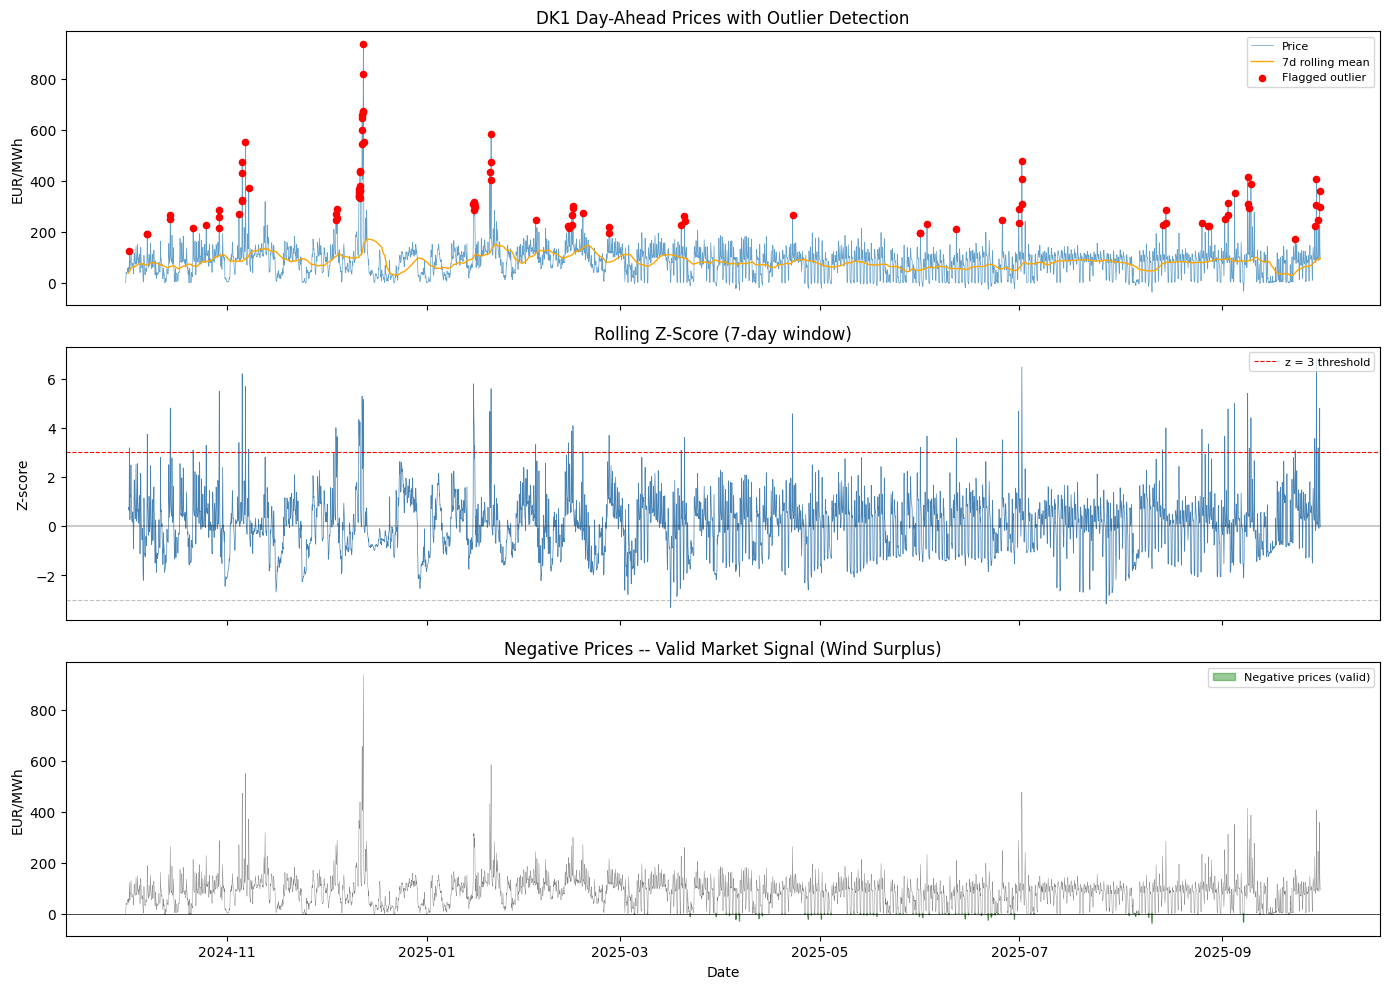

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Prices with rolling mean
ax = axes[0]
ax.plot(outlier_df.index, outlier_df["price"], linewidth=0.5, alpha=0.7, label="Price")
ax.plot(outlier_df.index, outlier_df["rolling_mean"], color="orange", linewidth=1, label="7d rolling mean")
# Mark outliers
outliers_mask = outlier_df["is_outlier"]
if outliers_mask.any():
    ax.scatter(
        outlier_df.index[outliers_mask],
        outlier_df["price"][outliers_mask],
        color="red", s=20, zorder=5, label="Flagged outlier",
    )
ax.set_ylabel("EUR/MWh")
ax.set_title("DK1 Day-Ahead Prices with Outlier Detection")
ax.legend(loc="upper right", fontsize=8)

# Panel 2: Z-scores
ax = axes[1]
ax.plot(outlier_df.index, outlier_df["z_score"], linewidth=0.5, color="steelblue")
ax.axhline(y=3.0, color="red", linestyle="--", linewidth=0.8, label="z = 3 threshold")
ax.axhline(y=-3.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(y=0, color="black", linewidth=0.3)
ax.set_ylabel("Z-score")
ax.set_title("Rolling Z-Score (7-day window)")
ax.legend(loc="upper right", fontsize=8)

# Panel 3: Negative prices highlighted (NOT outliers)
ax = axes[2]
negative_mask = price_series < 0
ax.fill_between(
    price_series.index, price_series, 0,
    where=negative_mask, color="green", alpha=0.4, label="Negative prices (valid)",
)
ax.plot(price_series.index, price_series, linewidth=0.3, color="black", alpha=0.5)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Date")
ax.set_title("Negative Prices -- Valid Market Signal (Wind Surplus)")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## Summary

| Concern | Approach |
|---|---|
| DST transitions | Store in UTC, convert to CET for display. `expected_hours_in_day()` handles 23/25h days. |
| Missing data | Forward-fill (max 6h), not interpolation. Generation has regime shifts, not smooth ramps. |
| Audit trail | Every imputed value logged with zone, column, timestamp, and method. |
| Negative prices | Valid market signal (wind surplus). The outlier detector only flags positive spikes. |